# Flattening an Eclipsing Binary Lightcurve Using BoxLeastSquares (BLS) and Lightkurve
## Author
Aidan Niklaus

## Citations and Acknowledgements
[Astropy](https://docs.astropy.org/en/latest/timeseries/bls.html), [Lightkurve](https://lightkurve.github.io/lightkurve/), [exoplanet](https://gallery.exoplanet.codes/tutorials/tess/)

## Learning Outcomes
At the end of this tutorial, students will be able to...
- Set up and run BLS on lightcurve data
- Use BLS outputs to create transit masks (i.e., mask off eclipses)
- Flatten lightcurves while applying a mask
- Phase-fold a lightcurve to find its true orbital period
- Detect initially undetected eclipses using orbital period and BLS re-runs
- Combine multiple masks using OR logic
- Plot lightcurves

## Keywords
BoxLeastSquares (BLS), eclipsing binary, mask, lightcurve, orbital period, phase-fold

## Summary
This tutorial demonstrates how to use Astropy's BoxLeastSquares method, in junction with Lightkurve, to effectively flatten an eclipsing binary lightcurve. Data masking and initial troubleshooting are included.

## Installation
If this is your first time using Lightkurve, you will need to install it using pip. This can be done in the terminal by typing "python -m pip install lightkurve --upgrade", or within Jupyter Notebook using the "%" prefix (code block below).

In [2]:
# I have already done this, so will comment it out to reduce the length of this tutorial

# # '--upgrade' automatically installs updates
# %pip install lightkurve --upgrade

## Imports

In [4]:
import numpy as np
import lightkurve as lk
from astropy.timeseries import BoxLeastSquares
import matplotlib.pyplot as plt
%matplotlib inline

## Step 0: The Problem
#### 0.1: Making an Example Lightkurve
In order to demonstrate Astropy's BoxLeastSqaures flattening method for eclipsing binaries, as well as why we need to use it, we first need an example lightcurve with which to work. The following code does this, but without much explanation. If you would like to learn in depth how to create a lightcurve from scratch, please refer to [THIS](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/03_FFI_LC_Decision_Tree_Tutorial.ipynb) tutorial *LINK INTRO OR JUST FFI PART?*. If you already have a lightcurve to work with, simply skip to "0.2: "We Cannot Simply Use 'flatten()'", noting that this tutorial stores it's lightcurve as the variable "lc".

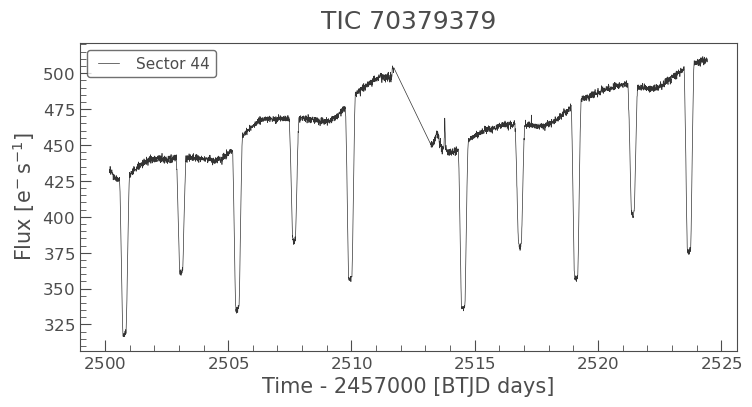

In [5]:
# Setting our target star and sector we will be using to make our lightcurve
target = "TIC 70379379"
sector = 44

# target : the star we want to work with; the following naming formats are acceptable
    # name, e.g. "HAT-P-11"
    # identifying number, e.g. "TIC 408036613"
    # RA Dec coordinates, e.g. "285.67942179 +50.24130576" (decimal format) or "19:02:43.1 +50:14:28.7" (sexagesimal format)
    # an astropy.coordinates.SkyCoord object
search_result = lk.search_tesscut(target=target, sector=sector)

# cutout_size : specifies the TPF size ("cropped" from the FFI), in this example, we asked for a 20x20 pixel TPF
tpf = search_result[0].download(cutout_size=20)

# Creating aperture mask of our target star
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

# Creating an initial lightcurve of our target star using our target mask
initial_lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Creating aperture mask of the background (to capture inherent background noise that is not taken out by quality mask)
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

# Grabbing the amount of pixels in each of our masks to ultimately use to filter out average background noise
n_target_pixels = target_mask.sum()
n_background_pixels = background_mask.sum()

# Making an average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve 
    # representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

# Subtracting the total noise lightcurve from the original lightcurve to get our corrected lightcurve
lc = initial_lc - noise_lc

# Plotting our lightcurve to see what we got!
lc.plot(title=target, label=f"Sector {sector}");

#### 0.2: We Cannot Simply Use 'flatten()'
Within the package Lightkurve is a built-in flattening function, so why can't we just use that? Well, let's try it...

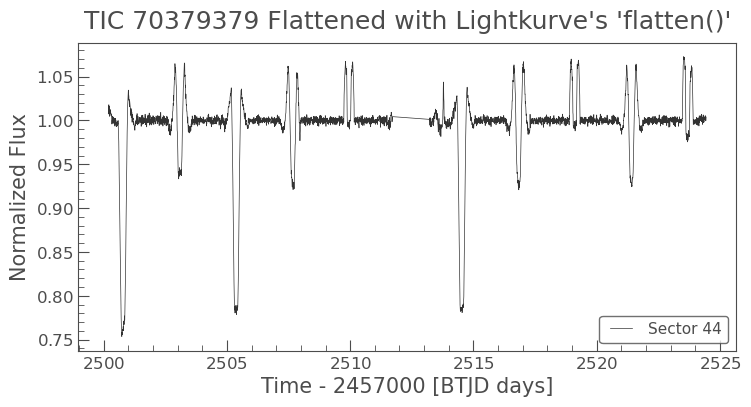

In [6]:
# Flattening the lightcurve above then replotting it
flat_lc = lc.flatten()
flat_lc.plot(title=f"{target} Flattened with Lightkurve's 'flatten()'", label=f"Sector {sector}");

As you can see, each eclipse has an up-spike before and after the dip, almost resembling shoulders. This is a result of Lightkurve's 'flatten()' function trying to fit our lightcurve with too low an order of polynomial, meaning its smooth nature prevents it from appropriately fitting the aggressive down-spikes customary of eclipsing binaries.

#### 0.3: The Fix
Astropy's BoxLeastSquares (BLS) fixes this issue by using square waves, as they are much more tailored to sharp dips. Utilizing this to better fit and detect our eclipses, we can mask them off when flattening our light curve, in turn getting rid of the "shoulders" and allowing us to clearly visualize our star.

## Step 1: Setting up BLS
Great! Now that we have a little context as to why we must use BLS, let's get started!

BLS requires two things to run: the data to which to fit itself and a list of possible orbital periods for our star, called a "period grid". Let's start by grabbing that data (which is conveniently held within the lightcurve we just made) and giving it to BLS. Note: BLS is simply receiving this data, not running or computing anything yet.

In [7]:
# Grabbing lc data and putitng into plain arrays that BLS accepts
time = lc.time.value
flux = lc.flux.value
# Don't technically need flux_err, but since lightkurve already gives it to us, might as well pass it along to BLS
flux_err = lc.flux_err.value

# Giving BLS the data it needs and creating the BLS model from it (no actual computation yet)
bls = BoxLeastSquares(time, flux, flux_err)

Next, let's make our period grid. If you already roughly know the period of your eclipsing binary, you can focus your grid to only include points around that area; but for this example, we will have our range be between 0.5 and 20 days as that should encompass most eclipsing binaries.

In [8]:
# Populating a list of potential period candidates --> 10,000 possible points between 0.5-20 days on a logarithmic scale
period_grid = np.exp(np.linspace(np.log(0.5), np.log(20), 10000))

## Step 2: Running BLS and Masking the Eclipses
Now that BLS has all the information it needs, let's run it!

In [9]:
# Actual computation occuring. For every possible period in our period grid, BLS...
    # Phase folds the data at that period
    # Tries to fit "boxes" on the eclipse
    # Groups all its attempts into eclipse or not-eclipse categories, which it uses to define a good fit model
# duration : variety of eclipse durations (in days) BLS will test
# oversample : higher = more accurate fits but slower, rarely need to go higher than 20
result = bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

Sweet! Now that BLS has run, there are a few things we want to grab from its result.
- the index of BLS's best guess for our star's period ('primary_result.power' is a periodogram BLS made, 'np.argmax' finds the index of the strongest peak (strongest peak = most likely period))

Using that index, we can grab:

- period
- reference eclipse time
- eclipse duration

We can use this information to create a mask of our eclipses and in turn prevent them from being inaccurately flattened.

In [10]:
# In order from top to bottom: index of BLS's best period guess, that period itself, reference eclipse time, eclipse duration
i = np.argmax(result.power)
period = result.period[i]
t0 = result.transit_time[i]
duration = result.duration[i]

# Creating the mask for our eclipses using the info grabbed above (true for points inside the eclipse, false for points outside)
    # Multiplying duration by 1.5 to pad the mask on either side to be safe
eclipse_mask = bls.transit_mask(time, period, duration * 1.5, t0)

Before we continue, it is always good practice to check our work. To do this, let's graph the mask we just made on top of our original lightcurve to ensure we masked the correct areas.

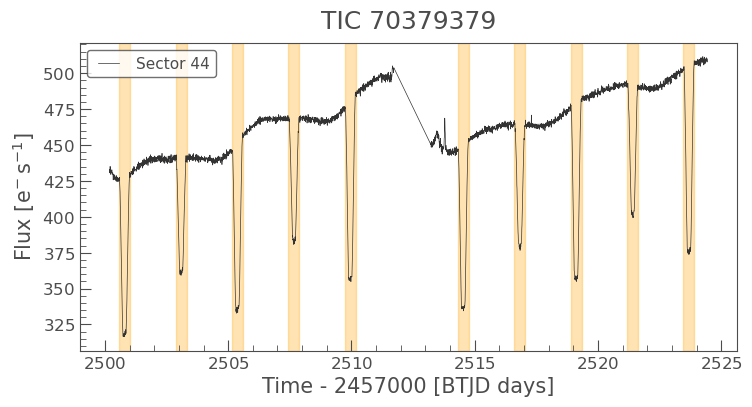

In [11]:
# Finding the edges of our mask
edges = np.diff(eclipse_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1

# Creating a plot of our original lightcurve
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value

# Overlaying the mask on the same plot we just made (orange = mask)
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

Fantastic! Now that we have confirmed our mask is sound, let's tell Lightkurve to flatten our graph again, except this time omit the eclipses.

Note: if your mask is not detecting all the eclipses, continue to the section titled "Bonus: Fixing Undetected Eclipses" later on in this tutorial.

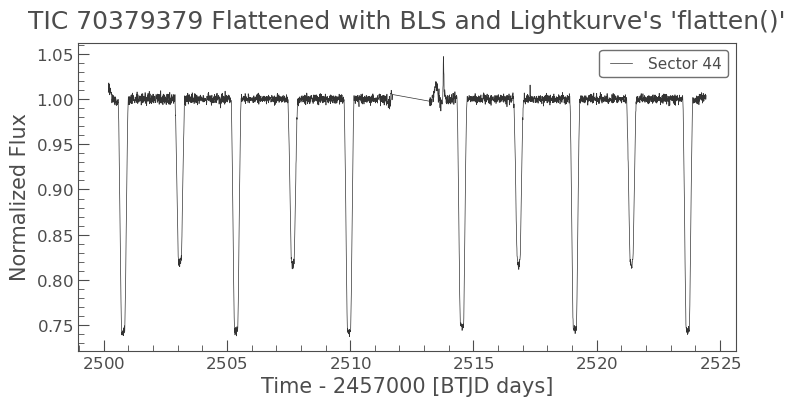

In [12]:
# Reflattening our lightcurve with the mask applied
BLS_flattened_lc = lc.flatten(mask=eclipse_mask)

# Plotting the newly flattened lightcurve to see what we got!
BLS_flattened_lc.plot(title=f"{target} Flattened with BLS and Lightkurve's 'flatten()'", label=f"Sector {sector}");

Very pretty! The shoulders are gone, the curve is flat, but the eclipses are preserved, just like we wanted! If all the eclipses that should be present are, then you are done. If some eclipses are missing, continue on to the bonus section.

## Bonus: Fixing Undetected Eclipses
Sometimes when working with noisier graphs and harder to detect eclipses, BLS may miss the less pronounced (secondary) eclipse. Luckily there is a fix for this! To demonstrate it, we first need an example lightcurve. The code block below does everything we just covered (minus the flattening) in order to catch us up to speed.
#### Setup

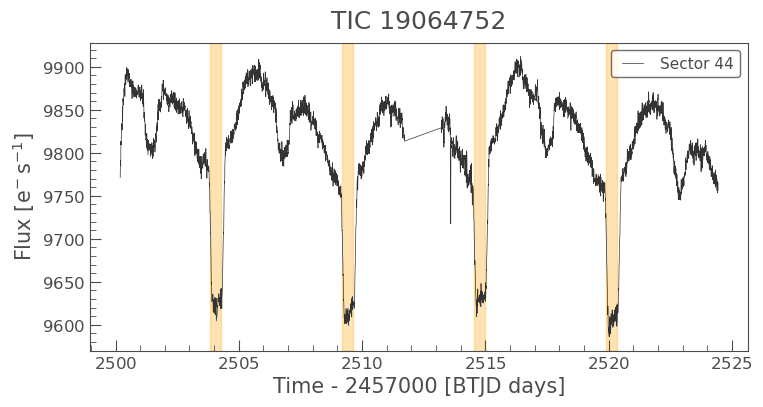

In [13]:
# Setting our target star and sector we will be using to make our lightcurve
target = "TIC 19064752"
sector = 44

# target : the star we want to work with; the following naming formats are acceptable
    # name, e.g. "HAT-P-11"
    # identifying number, e.g. "TIC 408036613"
    # RA Dec coordinates, e.g. "285.67942179 +50.24130576" (decimal format) or "19:02:43.1 +50:14:28.7" (sexagesimal format)
    # an astropy.coordinates.SkyCoord object
search_result = lk.search_tesscut(target=target, sector=sector)

# cutout_size : specifies the TPF size ("cropped" from the FFI), in this example, we asked for a 20x20 pixel TPF
tpf = search_result[0].download(cutout_size=20)

# Creating aperture mask of our target star
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

# Creating an initial lightcurve of our target star using our target mask
initial_lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Creating aperture mask of the background (to capture inherent background noise that is not taken out by quality mask)
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

# Grabbing the amount of pixels in each of our masks to ultimately use to filter out average background noise
n_target_pixels = target_mask.sum()
n_background_pixels = background_mask.sum()

# Making an average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve 
    # representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

# Subtracting the total noise lightcurve from the original lightcurve to get our corrected lightcurve
lc = initial_lc - noise_lc

# Grabbing lc data and putitng into plain arrays that BLS accepts
time = lc.time.value
flux = lc.flux.value
# Don't technically need flux_err, but since lightkurve already gives it to us, might as well pass it along to BLS
flux_err = lc.flux_err.value

# Giving BLS the data it needs and creating the BLS model from it (no actual computation yet)
bls = BoxLeastSquares(time, flux, flux_err)

# Populating a list of potential period candidates --> 10,000 possible points between 0.5-20 days on a logarithmic scale
period_grid = np.exp(np.linspace(np.log(0.5), np.log(20), 10000))

# Actual computation occuring. For every possible period in our period grid, BLS...
    # Phase folds the data at that period
    # Tries to fit "boxes" on the eclipse
    # Groups all its attempts into eclipse or not-eclipse categories, which it uses to define a good fit model
# duration : variety of durations (in days) BLS will test eclipses at
# oversample : higher = more accurate fits but slower, rarely need to go higher than 20
result = bls.power(period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

# In order from top to bottom: index of BLS's best period guess, that period itself, reference eclipse time, eclipse duration
i = np.argmax(result.power)
period = result.period[i]
t0 = result.transit_time[i]
duration = result.duration[i]

# Creating the mask for our primary eclipse using the info grabbed above (true for points inside the eclipse, false for points outside)
    # Multiplying duration by 1.5 to pad the mask on either side to be safe
primary_mask = bls.transit_mask(time, period, duration * 1.5, t0)

# Finding the edges of our mask
edges = np.diff(primary_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1

# Creating our plot of our original lightcurve
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value

# Overlaying the mask on the same plot we just made (orange = mask)
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

As you can see, BLS has only detected the deeper (primary) eclipses. A great start, but a job incomplete. In order to detect the shallower (secondary) eclipses as well, we need to run BLS again, but this time with more precise information.

Whenever BLS runs, it provides a guess for the orbital period. We can use this to refine the period grid we give to BLS, and effectively tell BLS where to search for the undetected eclipses. Before we do this, however, we must make sure that the period guess BLS gave us is sound. This is done using a process called phase-folding, built into Lightkurve as the function "fold()".

#### Phase-Folding to Check Period Accuracy
Phase folding is essentially periodically cutting up your lightcurve then layering all those cuts on top of themselves. We can tell Lightkurve to fold our curve on the period guess BLS gave us during its original run, and we will know that period is accurate if our folded graph shows one full cycle. Let's try it out!

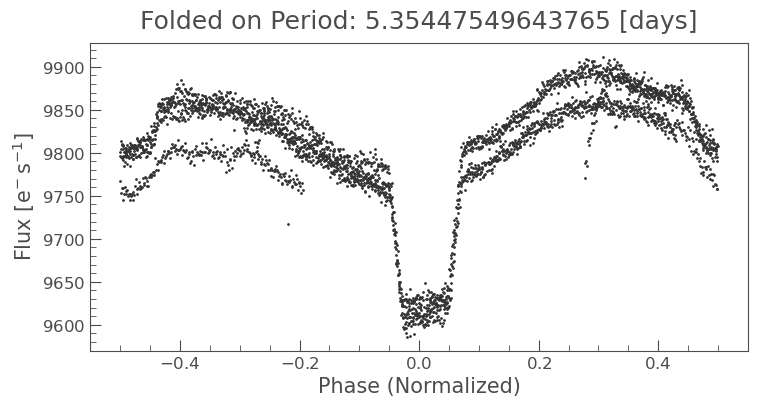

In [15]:
# Folding our lightcurve on the period BLS concluded on during its original run
    # period : orbital period we want to fold our graph on (increments to cut up our graph and then layer on top of each other)
    # epoch_time : reference start time (may need to adjust this to help with visual confirmation)
    # normalize_phase : makes time dimensionless value (helpful for visual confirmation)
folded_lc = lc.fold(period=period, epoch_time=t0, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {period} [days]");

That looks pretty promising! Let's shift the curve over slightly so we can fully see both eclipses. We can do this by either adding to, or subtracting from, the start/reference time.

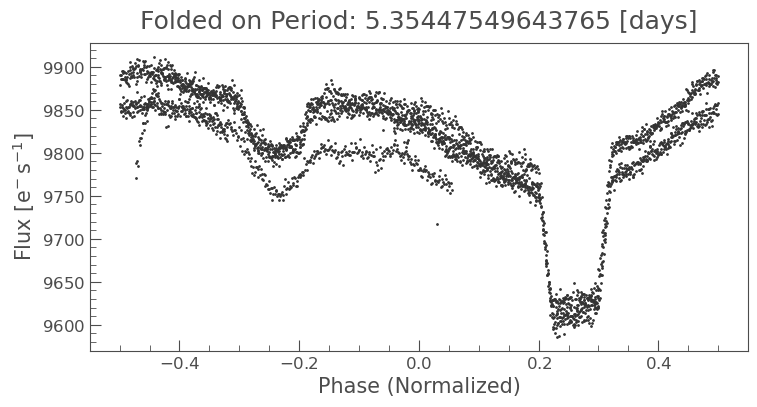

In [16]:
# Shifting our graph over by a quarter of a cycle and regraphing
folded_lc = lc.fold(period=period, epoch_time=t0 - period / 4, normalize_phase=True)
folded_lc.scatter(title=f"Folded on Period: {period} [days]");

Sweet! That is definitely one full cycle with both secondary and primary dips present; and visual confirmation that the period guess BLS gave us is sound. We can now confidently use it to hone in our secondary run.

#### Re-Running BLS to Detect the Secondary Eclipse
When asking BLS to look for shallower eclipses within our data, we want to adjust two things from the original run. First, we must ensure that BLS will not simply re-detect the deeper, primary eclipse. To do this, we can create a different mask that is completely opposite to the eclipse mask we already made. That way, when we apply it to our data, BLS will not look at any data points within the primary eclipse.

In [17]:
# Making another mask that is the exact opposite of the primary mask bc that way BLS only looks at points that are not part of the primary eclipse
not_primary_mask = ~primary_mask

# Applying the above mask to omit the primary eclipse from the data we give to BLS
secondary_bls = BoxLeastSquares(time[not_primary_mask], flux[not_primary_mask], flux_err[not_primary_mask])

The second thing we need to do is use the confirmed period to hone our period grid. As mentioned earlier, we are telling essentially telling BLS where to look as it will only search for eclipses that have our known period.

In [18]:
# New period grid that allocates all its "guesses" to our period + a little padding to be safe
    # Note: decreased from 10,000 (used in original run) to 1,000 guesses as we don't need all that computation for such a small range
secondary_period_grid = np.linspace(period * 0.99, period * 1.01, 1000)

With those two adaptions, we can run BLS for a second time, ultimately creating a mask for the secondary eclipse just like we did for the primary.

In [19]:
# Running BLS again with the masked data and updated more precise period grid
secondary_result = secondary_bls.power(secondary_period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

# Grabbing (in order from top to bottom): index of the period, the period itself, reference eclipse time, eclipse duration
secondary_i = np.argmax(secondary_result.power)
secondary_period = secondary_result.period[secondary_i]
secondary_t0 = secondary_result.transit_time[secondary_i]
secondary_duration = secondary_result.duration[secondary_i]

# Creating the secondary eclipse mask using the info grabbed above (padded the same as primary)
secondary_mask = secondary_bls.transit_mask(time, secondary_period, secondary_duration * 1.5, secondary_t0)

Great! Let's visually confirm we masked what we intended to.

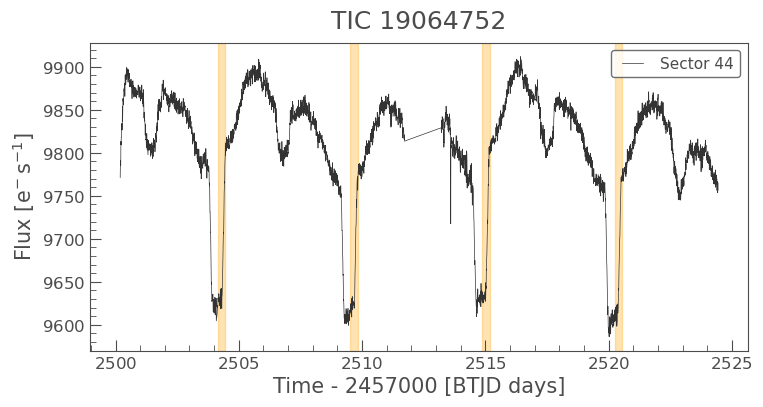

In [20]:
# Finding the edges of our mask
edges = np.diff(secondary_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1

# Creating our plot of our original lightcurve
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value

# Overlaying the mask on the same plot we just made (orange = mask)
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

Not quite what we were expecting! This is a great example of why it is so important to intermittently confirm our hypotheses. If we hadn't, we would never have known that our mask is not grabbing the secondary eclipse at all! Instead it looks like it is grabbing part of the primary eclipse, which probably means we didn't quite mask off all of it during our initial run. Let's take another look at our initial graph and see if we can find any clues.

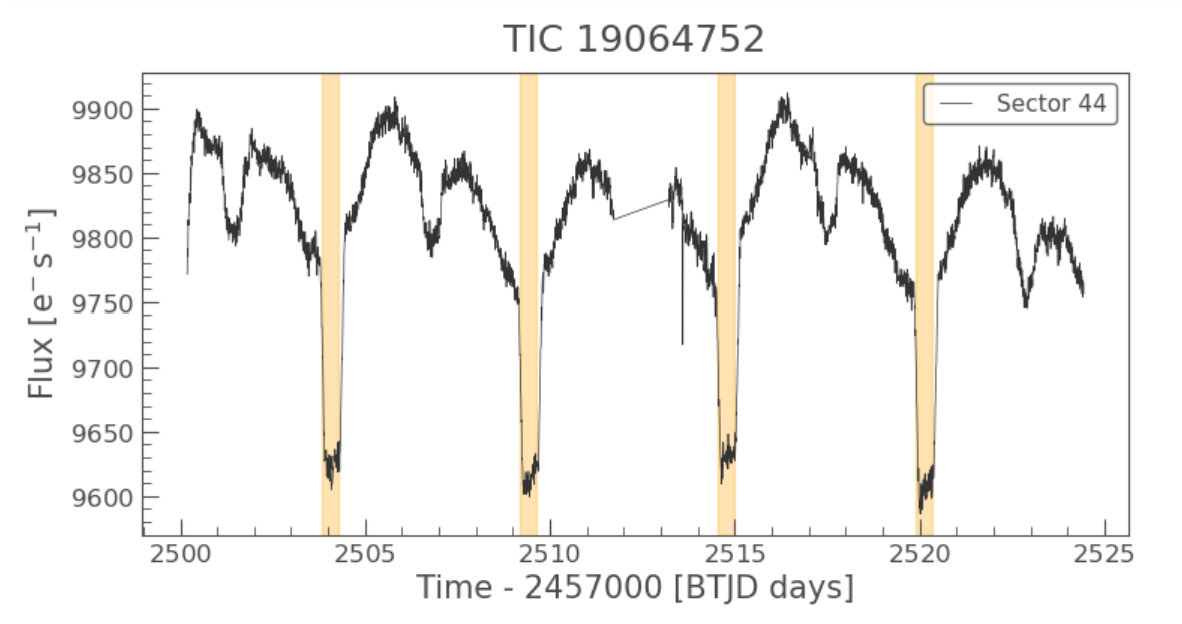

We are definitely finding the eclipses properly, but by zooming in a little we can see that indeed we missed part of the primary eclipse in our mask (specifically the egress and maybe some ingress too). This happens because BLS automatically locks on to the deepest dips, meaning that if any part of the primary eclipse is still present, it will favor that over everything else. Luckily there's an easy fix: pad the primary mask a little more and run the secondary BLS detection again.

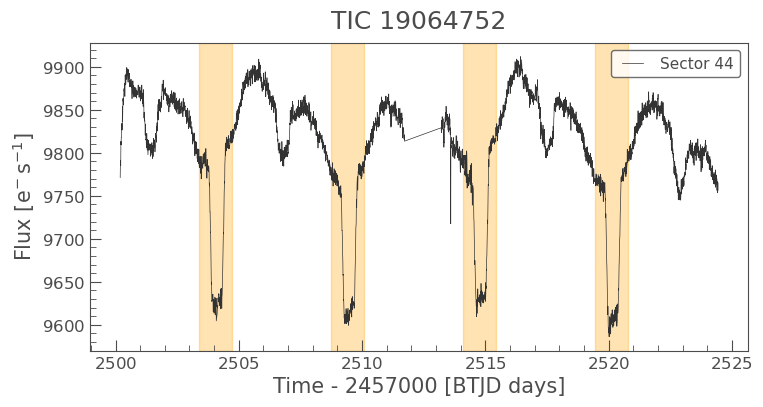

In [21]:
# Remaking our primary_mask but padded by 4.5x instead of 1.5x
primary_mask = bls.transit_mask(time, period, duration * 4.5, t0)

# Replotting the primary mask on top of our lightcurve
edges = np.diff(primary_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

Good, we definitely aren't miss anything now. Let's rerun the secondary BLS and see if it helped.

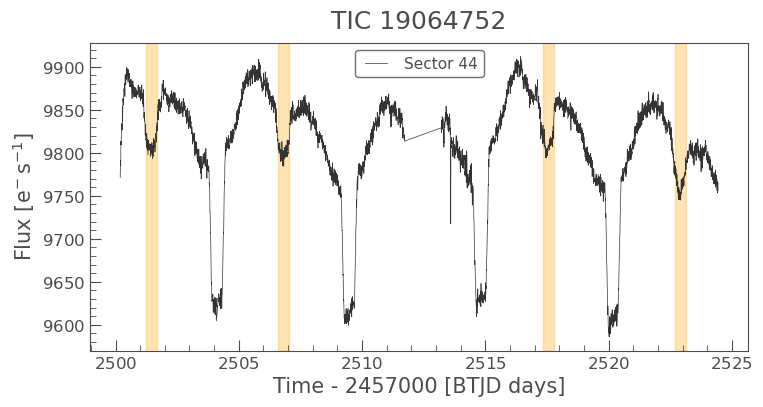

In [22]:
# Same re-running process as we did previously
    # With the extra padded primary mask, the masked data we give to BLS for this run will definitely not have any primary eclipse parts
not_primary_mask = ~primary_mask
secondary_bls = BoxLeastSquares(time[not_primary_mask], flux[not_primary_mask], flux_err[not_primary_mask])
secondary_result = secondary_bls.power(secondary_period_grid, duration=[0.02, 0.05, 0.1, 0.2, 0.3], oversample=20)

# Grabbing (in order from top to bottom): index of the period, the period itself, reference eclipse time, eclipse duration
secondary_i = np.argmax(secondary_result.power)
secondary_period = secondary_result.period[secondary_i]
secondary_t0 = secondary_result.transit_time[secondary_i]
secondary_duration = secondary_result.duration[secondary_i]
# Creating the secondary eclipse mask using the info grabbed above (padded normal 1.5x amount)
secondary_mask = secondary_bls.transit_mask(time, secondary_period, secondary_duration * 1.5, secondary_t0)

# Plotting the new secondary mask on top of our lightcurve
edges = np.diff(secondary_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

Fantastic! We have successfully detected and masked the secondary eclipse. Now we can combine the primary and secondary masks to create our full eclipse mask to use when we flatten.

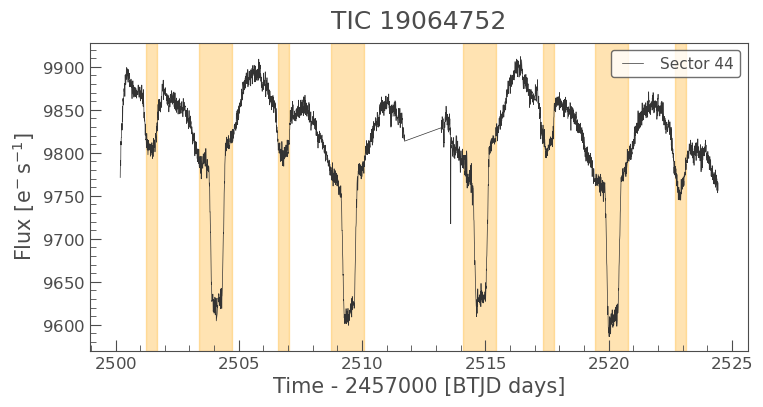

In [23]:
# Combining the two masks using OR logic
eclipse_mask = primary_mask | secondary_mask

# Plotting the full eclipse mask on top of our lightcurve to ensure everything looks good before flattening
edges = np.diff(eclipse_mask.astype(int), prepend=0, append=0)
starts = np.where(edges == 1)[0]
ends = np.where(edges == -1)[0] - 1
ax = lc.plot(title=target, label=f"Sector {sector}")
time = lc.time.value
for s, e in zip(starts, ends):
    ax.axvspan(time[s], time[e], color='orange', alpha=0.3)

The full mask looks great! Now let's use it to finally flatten our lightcurve.

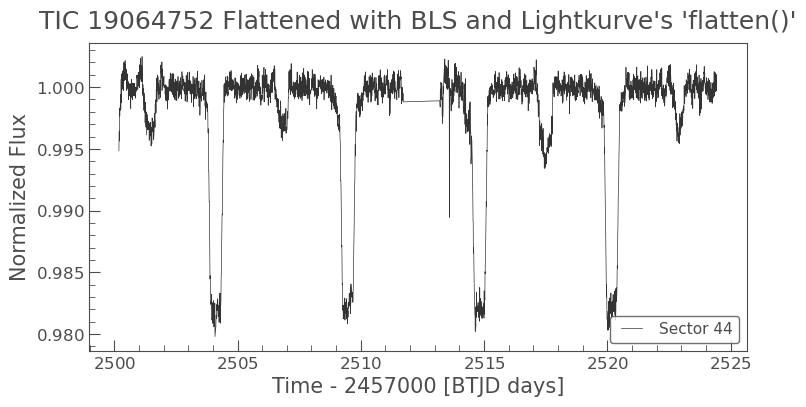

In [24]:
# Flattening the data with the eclipsing binary mask applied!
BLS_flattened_lc = lc.flatten(mask=eclipse_mask)

# Plotting the newly flattened lightcurve to see what we got!
BLS_flattened_lc.plot(title=f"{target} Flattened with BLS and Lightkurve's 'flatten()'", label=f"Sector {sector}");

Awesome, that's beautiful! Sometimes BLS doesn't perfectly detect every eclipse, but as we just learned, there is always a work-around.

Flattened lightcurves are very helpful to astronomers as they allow them to visualize star flux over time data without the signal of natural starspots. The flattening process can be challenging though when working with eclipsing binaries due to their harsh, dipping nature. Being able to use Astropy's BoxLeastSquares is the tool in your toolbox to fix this problem. As a reminder, the workflow for this tool is as follows:

## Workflow
- Give your lightcurve data to BLS
- Create a period grid that contains a range of possible periods for BLS to check
- Run BLS on your data using the period grid you just made
- Use the orbital period, eclipse duration, and reference time to create a mask of your eclipses
- Visually confirm all eclipses have been masked (Yes: flatten with eclipse masked then you are done; No: continue to next step)
- Check accuracy of BLS's period guess using phase folding (accurate period if one full cycle appears when curve is folded)
- Use that period to run BLS a second time (with honed in period grid and primary eclipse omitted from data)
- Visually confirm that previously undetected eclipses are now detected and masked (may need to pad primary eclipse mask more if still not detecting secondary eclipse)
- Combine primary and secondary masks to create full eclipse mask
- Flatten with full eclipse masked